In [1]:
import os
import glob
import sys
from datetime import datetime
import matplotlib.pyplot as plt
import random
import cv2
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Union
from dataclasses import dataclass, asdict
import math

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Number of available cpu: {os.cpu_count()}')

Using device: cuda
Number of available cpu: 4


In [2]:
!pip install albumentations

# Data Pipeline

In [3]:
# Standard library imports
import os
import json
import time
import random
import math
from dataclasses import dataclass
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Optional

# Third-party imports
import numpy as np
import torch
import albumentations as A
import cv2
from PIL import Image, ImageOps

# PyTorch data utilities
from torch.utils.data import Dataset, DataLoader

# Global constants...
TARGET_CATEGORIES = [
    "10_dress",
    "8_skirt",
    "43_ruffle",
    "1_top__t_shirt__sweatshirt",
    "0_shirt__blouse",
    "4_jacket",
    "9_coat",
    "2_sweater",
    "3_cardigan",
    "5_vest",
    "6_pants",
    "7_shorts",
]
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


### 1) Pipeline Configuration
Define tunable configuration for dataset paths, target categories, and sketch sampling ratios.

In [4]:

@dataclass
class PipelineConfig:
    """Configuration object for paired sketch-real samples."""

    real_root: str
    sketch_roots: Dict[str, str]
    categories: Tuple[str, ...] = tuple(TARGET_CATEGORIES)
    sketch_ratios: Dict[str, float] = None
    seed: int = 42

    def __post_init__(self):
        if self.sketch_ratios is None:
            self.sketch_ratios = {"hed": 0.5, "pencil": 0.3, "canny": 0.2}

        ratio_sum = sum(self.sketch_ratios.values())
        if not math.isclose(ratio_sum, 1.0, rel_tol=1e-6):
            raise ValueError(f"Sketch ratios must sum to 1.0, got {ratio_sum}")


### 2) Image Preprocessing Helpers
Prepare utility functions for consistent padding, resizing, and category-wise file indexing.

In [5]:
def list_category_images(root: Path, category: str) -> Dict[str, Path]:
    """Return a mapping from filename stem to image path for one category."""
    category_dir = root / category
    if not category_dir.exists():
        return {}

    return {
        p.stem: p
        for p in category_dir.iterdir()
        if p.suffix.lower() in IMG_EXTENSIONS
    }

### 3) Build Paired Metadata
Scan categories, match real and sketch files by stem, and assign sketch methods using the configured sampling ratios.

In [6]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from pathlib import Path
import json
import math
import random
import time
from collections import Counter







def build_gan_pairs(config: PipelineConfig) -> Tuple[List[dict], dict]:
    """Build paired sketch-real samples."""
    print("\n[1/3] Scanning categories, matching real-sketch files...")
    start_time = time.time()

    real_root = Path(config.real_root)
    sketch_roots = {k: Path(v) for k, v in config.sketch_roots.items()}
    rows: List[dict] = []
    skipped_no_sketch = 0

    for category in config.categories:
        real_images = list_category_images(real_root, category)
        if not real_images:
            continue

        sketch_index = {
            method: list_category_images(root, category)
            for method, root in sketch_roots.items()
        }

        for stem, real_path in real_images.items():
            candidates = {
                method: sketch_index[method][stem]
                for method in sketch_index
                if stem in sketch_index[method]
            }
            if not candidates:
                skipped_no_sketch += 1
                continue


            rows.append(
                {
                    "category": category,
                    "filename_stem": stem,
                    "real_path": str(real_path),
                    "sketch_candidates": candidates,
                    "available_methods": sorted(candidates.keys()),
                    
                }
            )

    print(f"Matched {len(rows)} pairs. Skipped {skipped_no_sketch} without sketches.")
    print("\n[2/3] Assigning sketch methods using ratio targets...")

    rng = random.Random(config.seed)
    total_found = len(rows)
    methods = list(config.sketch_ratios.keys())
    targets = {m: int(total_found * config.sketch_ratios[m]) for m in methods}
    remaining = dict(targets)

    indices = list(range(total_found))
    rng.shuffle(indices)

    for idx_step, idx in enumerate(indices):
        if idx_step % 20000 == 0 or idx_step == total_found - 1:
            print(f"Assigning sketch method: {idx_step + 1}/{total_found}")
        row = rows[idx]
        available = row["available_methods"]
        preferred = [m for m in available if remaining.get(m, 0) > 0]
        method = rng.choice(preferred) if preferred else rng.choice(available)

        row["sketch_method"] = method
        row["sketch_path"] = str(row["sketch_candidates"][method])
        if method in remaining:
            remaining[method] -= 1

    final_rows = [
        {
            "category": r["category"],
            "filename_stem": r["filename_stem"],
            "real_path": r["real_path"],
            "sketch_path": r["sketch_path"],
            "sketch_method": r["sketch_method"],
        }
        for r in rows
    ]

    duration = time.time() - start_time
    print(f"Data preparation completed in {duration:.2f}s.")

    summary = {
        "num_pairs": len(final_rows),
        "sketch_method_counts": dict(Counter(r["sketch_method"] for r in final_rows)),
        "skipped_no_sketch": skipped_no_sketch,
    }
    return final_rows, summary

### 4) Dataset and DataLoader
Define the PyTorch dataset and a reusable DataLoader builder with safe defaults.

In [7]:
# Cell 5
import os
from typing import List, Tuple, Optional
import numpy as np
import torch
import albumentations as A
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class SketchToRealGANDataset(Dataset):
    """PyTorch dataset that loads paired sketch-real images."""

    def __init__(
        self,
        rows: List[dict],
        image_size: int = 256,
        apply_augmentation: bool = False,
        flip_prob: float = 0.5,
        crop_scale: Tuple[float, float] = (0.9, 1.0),
        max_translate_ratio: float = 0.08,
        max_rotation_deg: float = 10.0,
        scale_range: Tuple[float, float] = (0.95, 1.05),
        # Thêm các tham số cho việc làm đứt nét Sketch
        sketch_degrade_prob: float = 0.7,
        degrade_holes_range: Tuple[int, int] = (5, 20),
        degrade_size_range: Tuple[int, int] = (10, 40),
    ):
        self.rows = rows
        self.image_size = image_size
        self.apply_augmentation = apply_augmentation
        
        # --- 1. SPATIAL AUGMENTATION (Áp dụng chung cho cả Real và Sketch để giữ align) ---
        max_shift_percent = max_translate_ratio * 100.0
        self._spatial_augment = A.Compose(
            [
                A.HorizontalFlip(p=flip_prob),
            ],
            additional_targets={"real": "image"},
        )

        # --- 2. SKETCH DEGRADATION (Chỉ áp dụng cho Sketch để ép model học nội suy) ---
        self._sketch_only_augment = A.Compose([])

    def _load_img(self, path: str) -> np.ndarray:
        img_bgr = cv2.imread(path)
        if img_bgr is None:
            raise ValueError(f"Could not load image: {path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        if img_rgb.shape[0] != self.image_size or img_rgb.shape[1] != self.image_size:
            img_rgb = cv2.resize(img_rgb, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        return img_rgb

    def _apply_spatial_augment_pair(
        self,
        sketch_img: np.ndarray,
        real_img: np.ndarray,
    ) -> Tuple[np.ndarray, np.ndarray]:
        transformed = self._spatial_augment(image=sketch_img, real=real_img)
        return transformed["image"], transformed["real"]

    def _to_tensor(self, img: np.ndarray) -> torch.Tensor:
        arr = img.astype(np.float32) / 127.5 - 1.0
        return torch.from_numpy(arr).permute(2, 0, 1)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        sketch_img = self._load_img(row["sketch_path"])
        real_img = self._load_img(row["real_path"])
        
        if self.apply_augmentation:
            # Bước 1: Augment không gian cho cả 2 ảnh để giữ sự đồng nhất
            sketch_img, real_img = self._apply_spatial_augment_pair(sketch_img, real_img)
            
            # Bước 2: Chỉ làm hỏng (degrade) ảnh Sketch
            sketch_img = self._sketch_only_augment(image=sketch_img)["image"]

        return {
            "sketch": self._to_tensor(sketch_img),
            "real": self._to_tensor(real_img),
            "filename_stem": row["filename_stem"],
        }


def build_gan_dataloader(
    rows: List[dict],
    batch_size: int = 16,
    image_size: int = 256,
    shuffle: bool = True,
    num_workers: Optional[int] = None,
    apply_augmentation: bool = False,
    sketch_degrade_prob: float = 0.7, 
) -> DataLoader:
    """Build a DataLoader from paired metadata rows."""
    if num_workers is None:
        num_workers = min(4, os.cpu_count() if os.cpu_count() is not None else 4)

    dataset = SketchToRealGANDataset(
        rows=rows,
        image_size=image_size,
        apply_augmentation=apply_augmentation,
        sketch_degrade_prob=sketch_degrade_prob,
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
        persistent_workers=True if num_workers > 0 else False,
        prefetch_factor=2 if num_workers > 0 else None,
    )

### 5) Run Pipeline and Quick Verification
Instantiate config, build pairs, create DataLoader, and run a short dry-run to validate input throughput.

In [8]:
import os
import cv2
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
from tqdm.auto import tqdm


def resize_single_image(args):
    src_path, dst_path, size = args
    try:
        img = cv2.imread(str(src_path))

        if img is not None:
            dst_path.parent.mkdir(parents=True, exist_ok=True)

            if img.shape[0] != size or img.shape[1] != size:
                img = cv2.resize(
                    img,
                    (size, size),
                    interpolation=cv2.INTER_LINEAR
                )

            cv2.imwrite(str(dst_path), img)
            return True

    except Exception as e:
        print(f"Error resizing {src_path}: {e}")

    return False


def preprocess_dataset_kaggle(
    real_root,
    sketch_roots,
    output_dir="/kaggle/working/resized_256",
    size=256,
):
    output_dir = Path(output_dir)

    print(f"Preprocessing images to {output_dir}...")

    tasks = []

    # =====================================================
    # 1. Scan real images
    # =====================================================
    real_in = Path(real_root)
    real_out = output_dir / "real"

    print("Scanning real images...")

    for cat in tqdm(
        TARGET_CATEGORIES,
        desc="Real categories",
        unit="cat"
    ):
        cat_dir = real_in / cat

        if not cat_dir.exists():
            continue

        for img_p in cat_dir.iterdir():
            if img_p.suffix.lower() in IMG_EXTENSIONS:
                dst_p = real_out / cat / img_p.name

                if not dst_p.exists():
                    tasks.append((img_p, dst_p, size))

    # =====================================================
    # 2. Scan sketch images
    # =====================================================
    print("Scanning sketch images...")

    for method, s_root in tqdm(
        sketch_roots.items(),
        desc="Sketch methods",
        unit="method"
    ):
        s_in = Path(s_root)
        s_out = output_dir / f"sketch_{method}"

        for cat in TARGET_CATEGORIES:
            cat_dir = s_in / cat

            if not cat_dir.exists():
                continue

            for img_p in cat_dir.iterdir():
                if img_p.suffix.lower() in IMG_EXTENSIONS:
                    dst_p = s_out / cat / img_p.name

                    if not dst_p.exists():
                        tasks.append((img_p, dst_p, size))

    print(f"\nTotal images to resize: {len(tasks):,}")

    # =====================================================
    # 3. Parallel resize with progress bar
    # =====================================================
    if tasks:
        max_workers = os.cpu_count() or 4

        print(f"Using {max_workers} workers...")

        with ProcessPoolExecutor(max_workers=max_workers) as executor:

            success_count = sum(
                tqdm(
                    executor.map(resize_single_image, tasks),
                    total=len(tasks),
                    desc="Resizing images",
                    unit="img",
                )
            )

        print(
            f"Finished. Successfully resized "
            f"{success_count:,}/{len(tasks):,} images."
        )

    else:
        print("All images are already resized. Skipping.")

    new_real_root = str(real_out)

    new_sketch_roots = {
        method: str(output_dir / f"sketch_{method}")
        for method in sketch_roots
    }

    return new_real_root, new_sketch_roots


# =========================================================
# MAIN PIPELINE
# =========================================================

print("Starting data pipeline...")

RAW_REAL_ROOT = (
    "/kaggle/input/datasets/vunhuduc/train-fashion-no-blur/"
    "(1)_images_filtered_no_bg"
)

RAW_SKETCH_ROOTS = {
    "hed": (
        "/kaggle/input/datasets/vunhuduc/train-sketch/"
        "fashion_category_filtered/(2)_sketch_hed"
    ),
    "pencil": (
        "/kaggle/input/datasets/vunhuduc/train-sketch/"
        "fashion_category_filtered/(2)_sketch_pencil"
    ),
    "canny": (
        "/kaggle/input/datasets/vunhuduc/train-sketch/"
        "fashion_category_filtered/(2)_sketch_canny"
    ),
}

# =========================================================
# STEP 1: Resize dataset
# =========================================================

resized_real, resized_sketches = preprocess_dataset_kaggle(
    RAW_REAL_ROOT,
    RAW_SKETCH_ROOTS,
    size=256,
)

# =========================================================
# STEP 2: Build metadata
# =========================================================

PIPE_CFG = PipelineConfig(
    real_root=resized_real,
    sketch_roots=resized_sketches,
)

print("\nBuilding sketch-real pairs...")

gan_rows, gan_summary = build_gan_pairs(PIPE_CFG)

print("\n" + "=" * 30)
print("PIPELINE SUMMARY:")
print(f"- Total paired samples: {gan_summary['num_pairs']:,}")

for method, count in gan_summary["sketch_method_counts"].items():
    print(f"  + {method}: {count:,} samples")

print("=" * 30)

# =========================================================
# STEP 3: DataLoader
# =========================================================

print("\nInitializing DataLoader...")

gan_loader = build_gan_dataloader(
    rows=gan_rows,
    batch_size=8,
    image_size=256,
    shuffle=True,
    apply_augmentation=True,
)

print(f"DataLoader ready. Total batches: {len(gan_loader):,}")

# =========================================================
# STEP 4: Dry run
# =========================================================

print("\nRunning dry-run for first 10 batches...")

for i, batch in enumerate(
    tqdm(
        gan_loader,
        total=min(10, len(gan_loader)),
        desc="Dry-run",
        unit="batch",
    )
):
    assert batch["sketch"].shape[1:] == (3, 256, 256)
    assert batch["real"].shape[1:] == (3, 256, 256)

    if i >= 9:
        break

print("\nPipeline is ready for training with sketch + z inputs.")

Starting data pipeline...
Preprocessing images to /kaggle/working/resized_256...
Scanning real images...


Real categories:   0%|          | 0/12 [00:00<?, ?cat/s]

Scanning sketch images...


Sketch methods:   0%|          | 0/3 [00:00<?, ?method/s]


Total images to resize: 265,176
Using 4 workers...


Resizing images:   0%|          | 0/265176 [00:00<?, ?img/s]

Finished. Successfully resized 265,176/265,176 images.

Building sketch-real pairs...

[1/3] Scanning categories, matching real-sketch files...
Matched 66294 pairs. Skipped 0 without sketches.

[2/3] Assigning sketch methods using ratio targets...
Assigning sketch method: 1/66294
Assigning sketch method: 20001/66294
Assigning sketch method: 40001/66294
Assigning sketch method: 60001/66294
Assigning sketch method: 66294/66294
Data preparation completed in 1.18s.

PIPELINE SUMMARY:
- Total paired samples: 66,294
  + pencil: 19,888 samples
  + canny: 13,259 samples
  + hed: 33,147 samples

Initializing DataLoader...
DataLoader ready. Total batches: 8,287

Running dry-run for first 10 batches...


Dry-run:   0%|          | 0/10 [00:00<?, ?batch/s]


Pipeline is ready for training with sketch + z inputs.


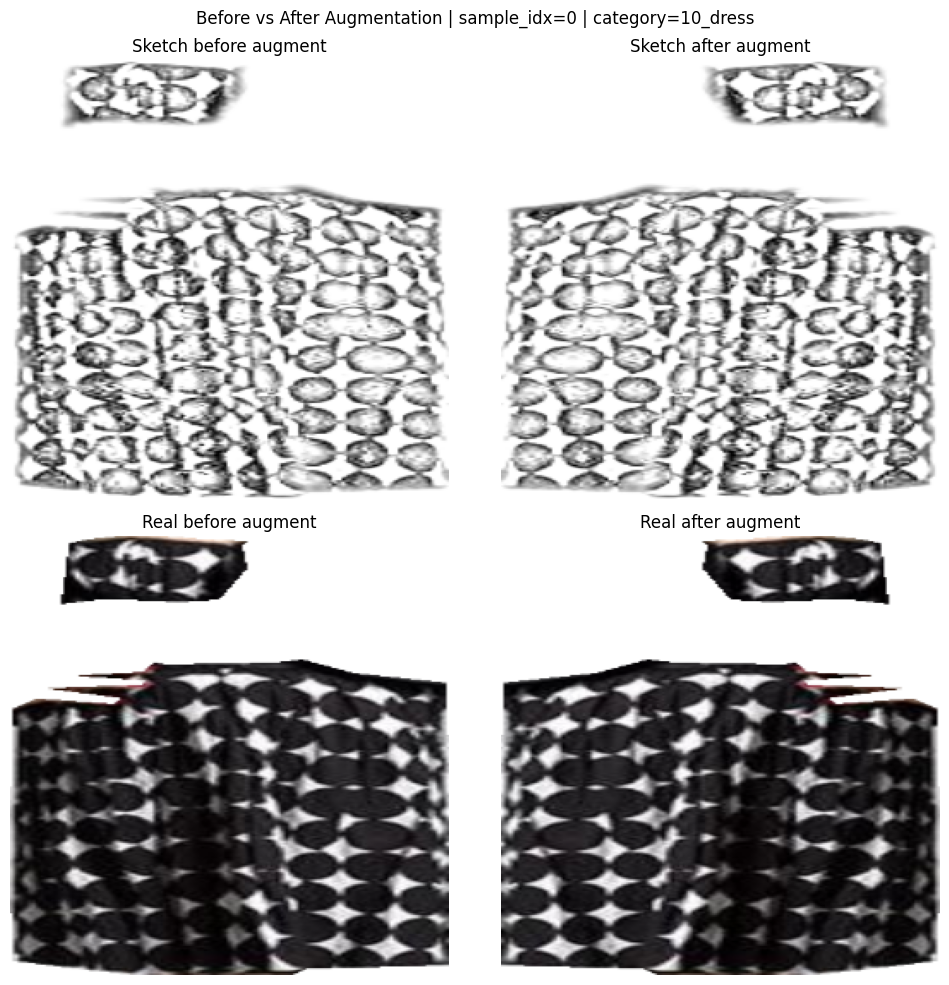

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path


def pil_to_uint8(image: Image.Image) -> np.ndarray:
    return np.asarray(image.convert("RGB"), dtype=np.uint8)


def tensor_to_uint8_img(tensor):
    """Convert a normalized CHW tensor in [-1, 1] to a displayable uint8 image."""
    image = tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = ((image + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    return image


def show_before_after_augment(sample_idx: int = 0):
    """Show images before and after augmentation for both sketch and real pairs."""
    if "gan_rows" not in globals() or len(gan_rows) == 0:
        print("gan_rows chưa có dữ liệu. Hãy chạy cell tạo DataLoader trước.")
        return

    if "SketchToRealGANDataset" not in globals():
        print("Dataset class chưa sẵn sàng. Hãy chạy cell Data Pipeline trước.")
        return

    sample = gan_rows[sample_idx]
    before_sketch = pil_to_uint8(Image.open(sample["sketch_path"]).convert("RGB"))
    before_real = pil_to_uint8(Image.open(sample["real_path"]).convert("RGB"))

    preview_dataset = SketchToRealGANDataset(
        rows=[sample],
        image_size=256,
        apply_augmentation=True,
    )
    aug_item = preview_dataset[0]
    after_sketch = tensor_to_uint8_img(aug_item["sketch"])
    after_real = tensor_to_uint8_img(aug_item["real"])

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    axes[0, 0].imshow(before_sketch)
    axes[0, 0].set_title("Sketch before augment")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(after_sketch)
    axes[0, 1].set_title("Sketch after augment")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(before_real)
    axes[1, 0].set_title("Real before augment")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(after_real)
    axes[1, 1].set_title("Real after augment")
    axes[1, 1].axis("off")

    plt.suptitle(f"Before vs After Augmentation | sample_idx={sample_idx} | category={sample['category']}")
    plt.tight_layout()
    plt.show()


show_before_after_augment(sample_idx=0)

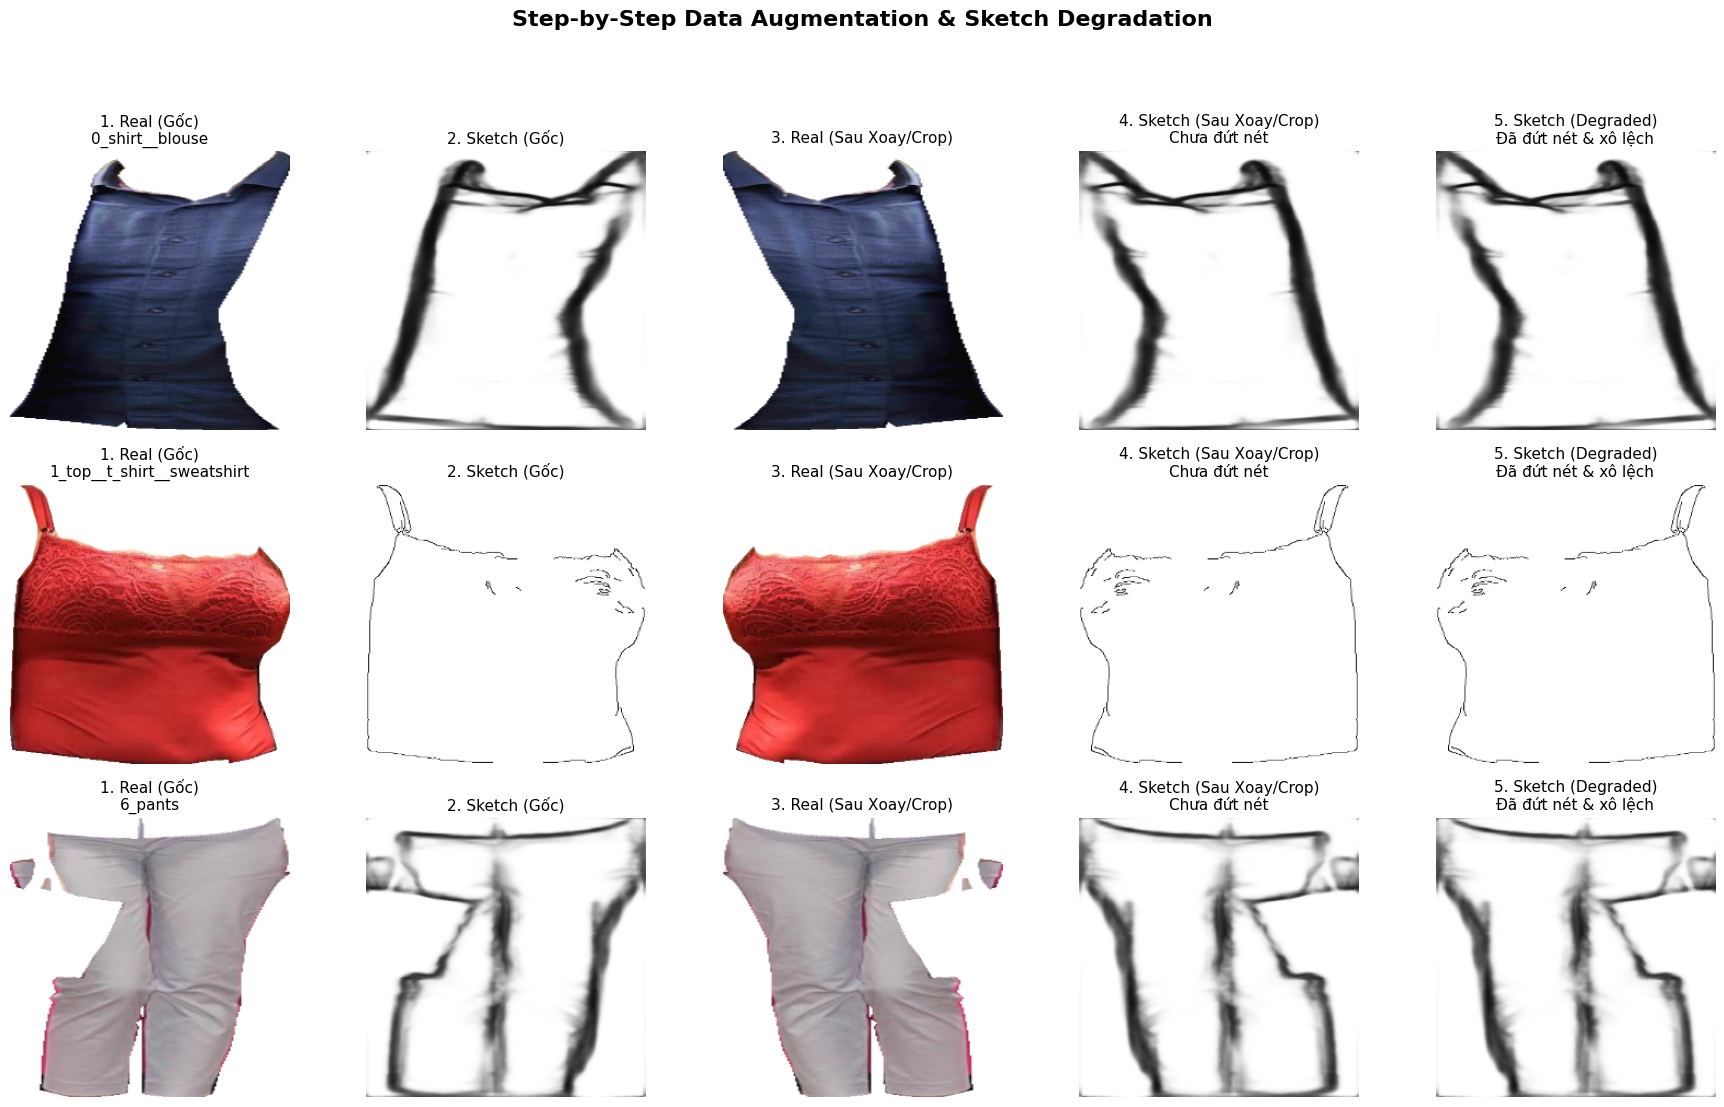

In [10]:
# Cell 8
import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_degradation_pipeline(dataset: SketchToRealGANDataset, num_samples: int = 3):
    """
    Trực quan hóa từng bước của quá trình Data Augmentation:
    Original -> Spatial Transform (cả 2) -> Degrade (chỉ Sketch)
    """
    if len(dataset) == 0:
        print("Dataset trống!")
        return

    # Lấy ngẫu nhiên các chỉ số
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    # Kích thước lưới: num_samples hàng, 5 cột (Real gốc, Sketch gốc, Real Spatial, Sketch Spatial, Sketch Degraded)
    fig, axes = plt.subplots(len(indices), 5, figsize=(18, 3.5 * len(indices)))
    
    # Xử lý trường hợp chỉ có 1 sample (axes sẽ là mảng 1D)
    if len(indices) == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        row = dataset.rows[idx]
        
        # 1. Load ảnh gốc (đã pad/resize)
        sketch_raw = dataset._load_img(row["sketch_path"])
        real_raw = dataset._load_img(row["real_path"])
        
        # 2. Áp dụng Spatial Augmentation (biến dạng không gian, áp dụng cho cả 2)
        transformed_spatial = dataset._spatial_augment(image=sketch_raw, real=real_raw)
        sketch_spatial = transformed_spatial["image"]
        real_spatial = transformed_spatial["real"]
        
        # 3. Áp dụng Sketch-only Augmentation (chỉ làm đứt nét/méo trên sketch)
        transformed_degrade = dataset._sketch_only_augment(image=sketch_spatial)
        sketch_degraded = transformed_degrade["image"]
        
        # --- Bắt đầu vẽ ---
        panels = [
            (real_raw, f"1. Real (Gốc)\n{row['category']}"),
            (sketch_raw, "2. Sketch (Gốc)"),
            (real_spatial, "3. Real (Sau Xoay/Crop)"),
            (sketch_spatial, "4. Sketch (Sau Xoay/Crop)\nChưa đứt nét"),
            (sketch_degraded, "5. Sketch (Degraded)\nĐã đứt nét & xô lệch"),
        ]
        
        for col, (img, title) in enumerate(panels):
            ax = axes[i][col]
            ax.imshow(img)
            ax.set_title(title, fontsize=11)
            ax.axis("off")
            
            # Thêm viền đỏ cho ảnh Degraded để dễ nhận biết
            if col == 4:
                for spine in ax.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(2)
                    spine.set_visible(True)

    plt.suptitle("Step-by-Step Data Augmentation & Sketch Degradation", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Lấy dataset từ dataloader đã tạo ở Cell 6 (hoặc khởi tạo mới)
# Đảm bảo bạn đã chạy Cell 5 (mới) và Cell 6 trước khi chạy code này
if 'gan_loader' in globals():
    my_dataset = gan_loader.dataset
    visualize_degradation_pipeline(my_dataset, num_samples=3)
else:
    print("Vui lòng khởi tạo 'gan_loader' trước.")

Hiển thị 4 mẫu | số cột: 9


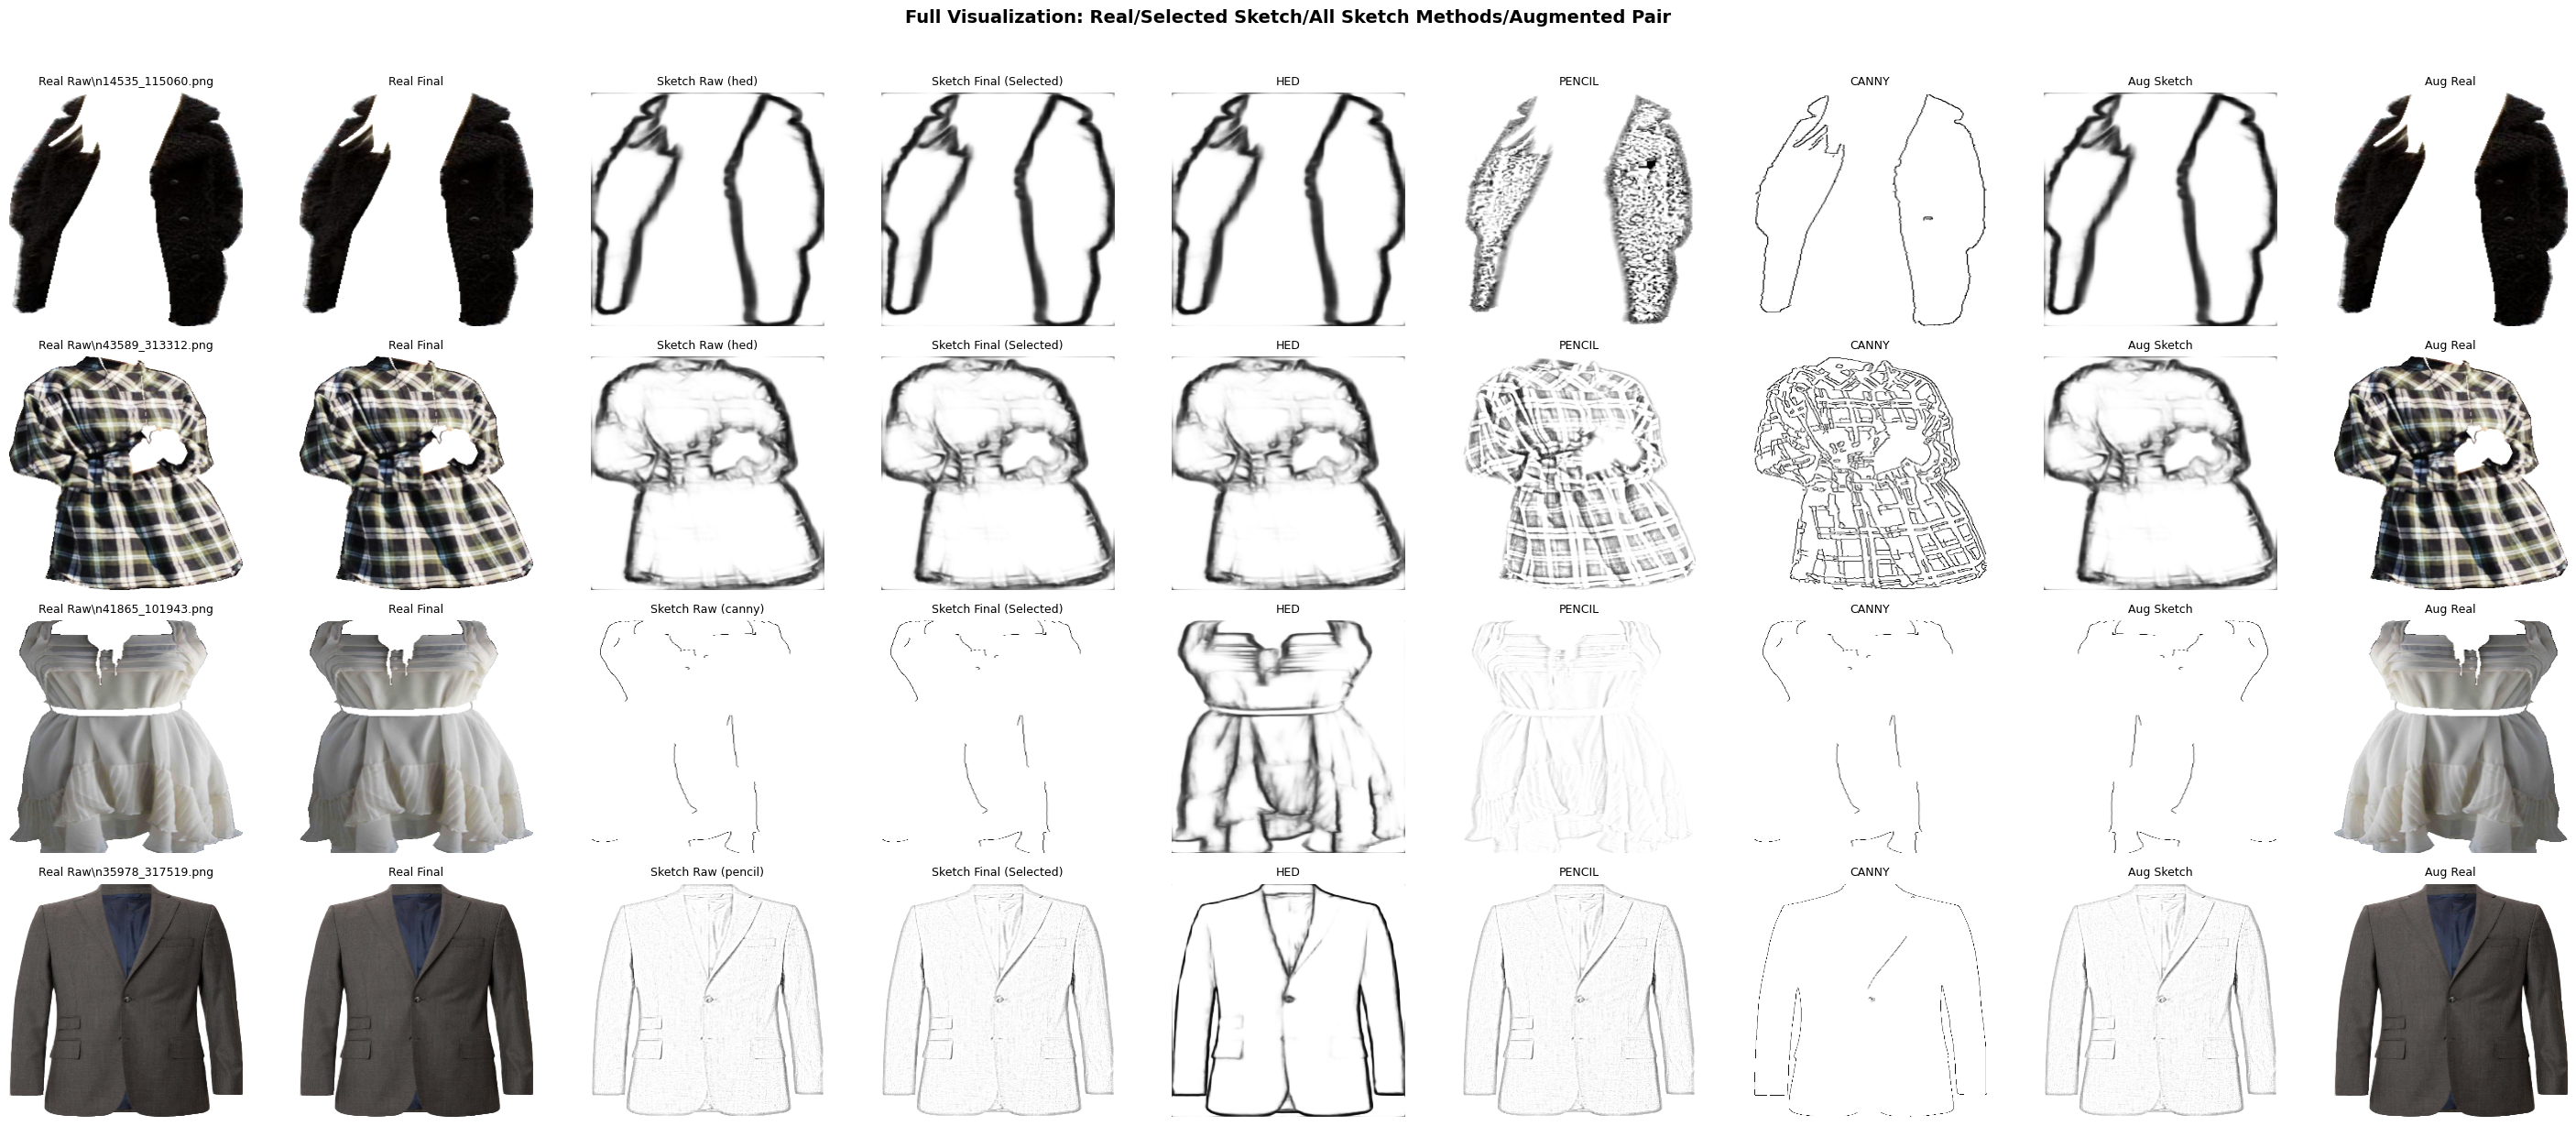

In [11]:
import matplotlib.pyplot as plt
import random
from pathlib import Path


def preprocess_preview(path: str, target_size: int = 256):
    """Return raw, smart-padded, and resized versions of one image."""
    with Image.open(path) as src_img:
        raw = src_img.convert("RGB")

    w, h = raw.size
    canvas_side = max(w, h, target_size)
    pad_left = (canvas_side - w) // 2
    pad_top = (canvas_side - h) // 2
    pad_right = canvas_side - w - pad_left
    pad_bottom = canvas_side - h - pad_top

    padded = ImageOps.expand(
        raw,
        border=(pad_left, pad_top, pad_right, pad_bottom),
        fill=(255, 255, 255),
    )
    resized = padded.resize((target_size, target_size), Image.BICUBIC)
    return raw, padded, resized


def find_sketch_by_method(row: dict, method: str):
    """Find sketch image path for a specific method using pipeline config roots."""
    if "PIPE_CFG" not in globals():
        return None

    root = PIPE_CFG.sketch_roots.get(method)
    if root is None:
        return None

    category = row["category"]
    stem = row["filename_stem"]
    method_dir = Path(root) / category
    if not method_dir.exists():
        return None

    for ext in IMG_EXTENSIONS:
        candidate = method_dir / f"{stem}{ext}"
        if candidate.exists():
            return str(candidate)
    return None


def tensor_to_uint8_img(t: torch.Tensor) -> np.ndarray:
    """Convert CHW tensor in [-1, 1] to HWC uint8 image."""
    arr = t.detach().cpu().permute(1, 2, 0).numpy()
    arr = ((arr + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    return arr


def visualize_full_samples(num_samples: int = 3, image_size: int = 256):
    """Visualize full sample information, including all sketch methods and augment result."""
    if "gan_rows" not in globals() or len(gan_rows) == 0:
        print("'gan_rows' chưa có dữ liệu. Hãy chạy Cell 15 trước.")
        return

    if "SketchToRealGANDataset" not in globals():
        print("Dataset class chưa sẵn sàng. Hãy chạy Cell 13 trước.")
        return

    sample_rows = random.sample(gan_rows, k=min(num_samples, len(gan_rows)))

    # Methods come from current config to guarantee complete per-method view.
    method_list = list(PIPE_CFG.sketch_roots.keys()) if "PIPE_CFG" in globals() else []

    # Build one augmented dataset instance to preview synchronized spatial augmentation.
    preview_dataset = SketchToRealGANDataset(
        rows=sample_rows,
        image_size=image_size,
        apply_augmentation=True,
    )

    # Columns: Real(raw/final), Selected Sketch(raw/final), each method final, augmented pair.
    n_cols = 4 + len(method_list) + 2
    fig, axes = plt.subplots(len(sample_rows), n_cols, figsize=(3.2 * n_cols, 3.0 * len(sample_rows)))
    if len(sample_rows) == 1:
        axes = [axes]

    print(f"Hiển thị {len(sample_rows)} mẫu | số cột: {n_cols}")

    for r, row in enumerate(sample_rows):
        # Real + selected sketch processing previews.
        real_raw, _, real_final = preprocess_preview(row["real_path"], target_size=image_size)
        sketch_raw, _, sketch_final = preprocess_preview(row["sketch_path"], target_size=image_size)

        # Augmented aligned pair preview.
        aug_item = preview_dataset[r]
        aug_sketch = tensor_to_uint8_img(aug_item["sketch"])
        aug_real = tensor_to_uint8_img(aug_item["real"])

        panels = [
            (real_raw, f"Real Raw\\n{Path(row['real_path']).name}"),
            (real_final, "Real Final"),
            (sketch_raw, f"Sketch Raw ({row['sketch_method']})"),
            (sketch_final, "Sketch Final (Selected)"),
        ]

        # Add each sketch type (hed/pencil/canny/...) for full comparison.
        for method in method_list:
            m_path = find_sketch_by_method(row, method)
            if m_path is None:
                blank = np.full((image_size, image_size, 3), 255, dtype=np.uint8)
                panels.append((blank, f"{method.upper()} (missing)"))
            else:
                _, _, m_final = preprocess_preview(m_path, target_size=image_size)
                panels.append((m_final, f"{method.upper()}"))

        panels.append((aug_sketch, "Aug Sketch"))
        panels.append((aug_real, "Aug Real"))

        for c, (img, title) in enumerate(panels):
            axes[r][c].imshow(img)
            axes[r][c].set_title(title, fontsize=9)
            axes[r][c].axis("off")

        # Write sample-level text at the first panel for quick traceability.
        axes[r][0].set_ylabel(
            f"Sample {r + 1}\\ncat: {row['category']}",
            rotation=90,
            fontsize=9,
            labelpad=10,
        )

    plt.suptitle(
        "Full Visualization: Real/Selected Sketch/All Sketch Methods/Augmented Pair",
        y=1.02,
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


# Run visualization
visualize_full_samples(num_samples=4, image_size=256)

# Mobile Sketch2Image (MS2I) Network Implementation

## Common Blocks

## MUNIT Architecture Components

This section contains the MUNIT building blocks: ResBlocks, Encoders, Decoders.


In [12]:
"""
Copyright (C) 2018 NVIDIA Corporation.  All rights reserved.
Licensed under the CC BY-NC-SA 4.0 license (https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode).
"""
from torch import nn
from torch.autograd import Variable
import torch
import torch.nn.functional as F
try:
    from itertools import izip as zip
except ImportError: # will be 3.x series
    pass

##################################################################################
# Discriminator
##################################################################################

class MsImageDis(nn.Module):
    # Multi-scale discriminator architecture
    def __init__(self, input_dim, params):
        super(MsImageDis, self).__init__()
        self.n_layer = params['n_layer']
        self.gan_type = params['gan_type']
        self.dim = params['dim']
        self.norm = params['norm']
        self.activ = params['activ']
        self.num_scales = params['num_scales']
        self.pad_type = params['pad_type']
        self.input_dim = input_dim
        self.downsample = nn.AvgPool2d(3, stride=2, padding=[1, 1], count_include_pad=False)
        self.cnns = nn.ModuleList()
        for _ in range(self.num_scales):
            self.cnns.append(self._make_net())

    def _make_net(self):
        dim = self.dim
        cnn_x = []
        cnn_x += [Conv2dBlock(self.input_dim, dim, 4, 2, 1, norm='none', activation=self.activ, pad_type=self.pad_type)]
        for i in range(self.n_layer - 1):
            cnn_x += [Conv2dBlock(dim, dim * 2, 4, 2, 1, norm=self.norm, activation=self.activ, pad_type=self.pad_type)]
            dim *= 2
        cnn_x += [nn.Conv2d(dim, 1, 1, 1, 0)]
        cnn_x = nn.Sequential(*cnn_x)
        return cnn_x

    def forward(self, x):
        outputs = []
        for model in self.cnns:
            outputs.append(model(x))
            x = self.downsample(x)
        return outputs

    def calc_dis_loss(self, input_fake, input_real):
        # calculate the loss to train D
        outs0 = self.forward(input_fake)
        outs1 = self.forward(input_real)
        loss = 0

        for it, (out0, out1) in enumerate(zip(outs0, outs1)):
            if self.gan_type == 'lsgan':
                loss += torch.mean((out0 - 0)**2) + torch.mean((out1 - 1)**2)
            elif self.gan_type == 'nsgan':
                all0 = Variable(torch.zeros_like(out0.data).cuda(), requires_grad=False)
                all1 = Variable(torch.ones_like(out1.data).cuda(), requires_grad=False)
                loss += torch.mean(F.binary_cross_entropy(F.sigmoid(out0), all0) +
                                   F.binary_cross_entropy(F.sigmoid(out1), all1))
            else:
                assert 0, "Unsupported GAN type: {}".format(self.gan_type)
        return loss

    def calc_gen_loss(self, input_fake):
        # calculate the loss to train G
        outs0 = self.forward(input_fake)
        loss = 0
        for it, (out0) in enumerate(outs0):
            if self.gan_type == 'lsgan':
                loss += torch.mean((out0 - 1)**2) # LSGAN
            elif self.gan_type == 'nsgan':
                all1 = Variable(torch.ones_like(out0.data).cuda(), requires_grad=False)
                loss += torch.mean(F.binary_cross_entropy(F.sigmoid(out0), all1))
            else:
                assert 0, "Unsupported GAN type: {}".format(self.gan_type)
        return loss

##################################################################################
# Generator
##################################################################################

class AdaINGen(nn.Module):
    # AdaIN auto-encoder architecture
    def __init__(self, input_dim, params):
        super(AdaINGen, self).__init__()
        dim = params['dim']
        style_dim = params['style_dim']
        n_downsample = params['n_downsample']
        n_res = params['n_res']
        activ = params['activ']
        pad_type = params['pad_type']
        mlp_dim = params['mlp_dim']

        # style encoder
        self.enc_style = StyleEncoder(4, input_dim, dim, style_dim, norm='none', activ=activ, pad_type=pad_type)

        # content encoder
        self.enc_content = ContentEncoder(n_downsample, n_res, input_dim, dim, 'in', activ, pad_type=pad_type)
        self.dec = Decoder(n_downsample, n_res, self.enc_content.output_dim, input_dim, res_norm='adain', activ=activ, pad_type=pad_type)

        # MLP to generate AdaIN parameters
        self.mlp = MLP(style_dim, self.get_num_adain_params(self.dec), mlp_dim, 3, norm='none', activ=activ)

    def forward(self, images):
        # reconstruct an image
        content, style_fake = self.encode(images)
        images_recon = self.decode(content, style_fake)
        return images_recon

    def encode(self, images):
        # encode an image to its content and style codes
        style_fake = self.enc_style(images)
        content = self.enc_content(images)
        return content, style_fake

    def decode(self, content, style):
        # decode content and style codes to an image
        adain_params = self.mlp(style)
        self.assign_adain_params(adain_params, self.dec)
        images = self.dec(content)
        return images

    def assign_adain_params(self, adain_params, model):
        # assign the adain_params to the AdaIN layers in model
        for m in model.modules():
            if m.__class__.__name__ == "AdaptiveInstanceNorm2d":
                mean = adain_params[:, :m.num_features]
                std = adain_params[:, m.num_features:2*m.num_features]
                m.bias = mean.contiguous().view(-1)
                m.weight = std.contiguous().view(-1)
                if adain_params.size(1) > 2*m.num_features:
                    adain_params = adain_params[:, 2*m.num_features:]

    def get_num_adain_params(self, model):
        # return the number of AdaIN parameters needed by the model
        num_adain_params = 0
        for m in model.modules():
            if m.__class__.__name__ == "AdaptiveInstanceNorm2d":
                num_adain_params += 2*m.num_features
        return num_adain_params


class VAEGen(nn.Module):
    # VAE architecture
    def __init__(self, input_dim, params):
        super(VAEGen, self).__init__()
        dim = params['dim']
        n_downsample = params['n_downsample']
        n_res = params['n_res']
        activ = params['activ']
        pad_type = params['pad_type']

        # content encoder
        self.enc = ContentEncoder(n_downsample, n_res, input_dim, dim, 'in', activ, pad_type=pad_type)
        self.dec = Decoder(n_downsample, n_res, self.enc.output_dim, input_dim, res_norm='in', activ=activ, pad_type=pad_type)

    def forward(self, images):
        # This is a reduced VAE implementation where we assume the outputs are multivariate Gaussian distribution with mean = hiddens and std_dev = all ones.
        hiddens = self.encode(images)
        if self.training == True:
            noise = Variable(torch.randn(hiddens.size()).cuda(hiddens.data.get_device()))
            images_recon = self.decode(hiddens + noise)
        else:
            images_recon = self.decode(hiddens)
        return images_recon, hiddens

    def encode(self, images):
        hiddens = self.enc(images)
        noise = Variable(torch.randn(hiddens.size()).cuda(hiddens.data.get_device()))
        return hiddens, noise

    def decode(self, hiddens):
        images = self.dec(hiddens)
        return images


##################################################################################
# Encoder and Decoders
##################################################################################

class StyleEncoder(nn.Module):
    def __init__(self, n_downsample, input_dim, dim, style_dim, norm, activ, pad_type):
        super(StyleEncoder, self).__init__()
        self.model = []
        self.model += [Conv2dBlock(input_dim, dim, 7, 1, 3, norm=norm, activation=activ, pad_type=pad_type)]
        for i in range(2):
            self.model += [Conv2dBlock(dim, 2 * dim, 4, 2, 1, norm=norm, activation=activ, pad_type=pad_type)]
            dim *= 2
        for i in range(n_downsample - 2):
            self.model += [Conv2dBlock(dim, dim, 4, 2, 1, norm=norm, activation=activ, pad_type=pad_type)]
        self.model += [nn.AdaptiveAvgPool2d(1)] # global average pooling
        self.model += [nn.Conv2d(dim, style_dim, 1, 1, 0)]
        self.model = nn.Sequential(*self.model)
        self.output_dim = dim

    def forward(self, x):
        return self.model(x)

class ContentEncoder(nn.Module):
    def __init__(self, n_downsample, n_res, input_dim, dim, norm, activ, pad_type):
        super(ContentEncoder, self).__init__()
        self.model = []
        self.model += [Conv2dBlock(input_dim, dim, 7, 1, 3, norm=norm, activation=activ, pad_type=pad_type)]
        # downsampling blocks
        for i in range(n_downsample):
            self.model += [Conv2dBlock(dim, 2 * dim, 4, 2, 1, norm=norm, activation=activ, pad_type=pad_type)]
            dim *= 2
        # residual blocks
        self.model += [ResBlocks(n_res, dim, norm=norm, activation=activ, pad_type=pad_type)]
        self.model = nn.Sequential(*self.model)
        self.output_dim = dim

    def forward(self, x):
        return self.model(x)

class Decoder(nn.Module):
    def __init__(self, n_upsample, n_res, dim, output_dim, res_norm='adain', activ='relu', pad_type='zero'):
        super(Decoder, self).__init__()

        self.model = []
        # AdaIN residual blocks
        self.model += [ResBlocks(n_res, dim, res_norm, activ, pad_type=pad_type)]
        # upsampling blocks
        for i in range(n_upsample):
            self.model += [nn.Upsample(scale_factor=2),
                           Conv2dBlock(dim, dim // 2, 5, 1, 2, norm='ln', activation=activ, pad_type=pad_type)]
            dim //= 2
        # use reflection padding in the last conv layer
        self.model += [Conv2dBlock(dim, output_dim, 7, 1, 3, norm='none', activation='tanh', pad_type=pad_type)]
        self.model = nn.Sequential(*self.model)

    def forward(self, x):
        return self.model(x)

##################################################################################
# Sequential Models
##################################################################################
class ResBlocks(nn.Module):
    def __init__(self, num_blocks, dim, norm='in', activation='relu', pad_type='zero'):
        super(ResBlocks, self).__init__()
        self.model = []
        for i in range(num_blocks):
            self.model += [ResBlock(dim, norm=norm, activation=activation, pad_type=pad_type)]
        self.model = nn.Sequential(*self.model)

    def forward(self, x):
        return self.model(x)

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, dim, n_blk, norm='none', activ='relu'):

        super(MLP, self).__init__()
        self.model = []
        self.model += [LinearBlock(input_dim, dim, norm=norm, activation=activ)]
        for i in range(n_blk - 2):
            self.model += [LinearBlock(dim, dim, norm=norm, activation=activ)]
        self.model += [LinearBlock(dim, output_dim, norm='none', activation='none')] # no output activations
        self.model = nn.Sequential(*self.model)

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))

##################################################################################
# Basic Blocks
##################################################################################
class ResBlock(nn.Module):
    def __init__(self, dim, norm='in', activation='relu', pad_type='zero'):
        super(ResBlock, self).__init__()

        model = []
        model += [Conv2dBlock(dim ,dim, 3, 1, 1, norm=norm, activation=activation, pad_type=pad_type)]
        model += [Conv2dBlock(dim ,dim, 3, 1, 1, norm=norm, activation='none', pad_type=pad_type)]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        residual = x
        out = self.model(x)
        out += residual
        return out

class Conv2dBlock(nn.Module):
    def __init__(self, input_dim ,output_dim, kernel_size, stride,
                 padding=0, norm='none', activation='relu', pad_type='zero'):
        super(Conv2dBlock, self).__init__()
        self.use_bias = True
        # initialize padding
        if pad_type == 'reflect':
            self.pad = nn.ReflectionPad2d(padding)
        elif pad_type == 'replicate':
            self.pad = nn.ReplicationPad2d(padding)
        elif pad_type == 'zero':
            self.pad = nn.ZeroPad2d(padding)
        else:
            assert 0, "Unsupported padding type: {}".format(pad_type)

        # initialize normalization
        norm_dim = output_dim
        if norm == 'bn':
            self.norm = nn.BatchNorm2d(norm_dim)
        elif norm == 'in':
            #self.norm = nn.InstanceNorm2d(norm_dim, track_running_stats=True)
            self.norm = nn.InstanceNorm2d(norm_dim)
        elif norm == 'ln':
            self.norm = LayerNorm(norm_dim)
        elif norm == 'adain':
            self.norm = AdaptiveInstanceNorm2d(norm_dim)
        elif norm == 'none' or norm == 'sn':
            self.norm = None
        else:
            assert 0, "Unsupported normalization: {}".format(norm)

        # initialize activation
        if activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        elif activation == 'lrelu':
            self.activation = nn.LeakyReLU(0.2, inplace=True)
        elif activation == 'prelu':
            self.activation = nn.PReLU()
        elif activation == 'selu':
            self.activation = nn.SELU(inplace=True)
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        elif activation == 'none':
            self.activation = None
        else:
            assert 0, "Unsupported activation: {}".format(activation)

        # initialize convolution
        if norm == 'sn':
            self.conv = SpectralNorm(nn.Conv2d(input_dim, output_dim, kernel_size, stride, bias=self.use_bias))
        else:
            self.conv = nn.Conv2d(input_dim, output_dim, kernel_size, stride, bias=self.use_bias)

    def forward(self, x):
        x = self.conv(self.pad(x))
        if self.norm:
            x = self.norm(x)
        if self.activation:
            x = self.activation(x)
        return x

class LinearBlock(nn.Module):
    def __init__(self, input_dim, output_dim, norm='none', activation='relu'):
        super(LinearBlock, self).__init__()
        use_bias = True
        # initialize fully connected layer
        if norm == 'sn':
            self.fc = SpectralNorm(nn.Linear(input_dim, output_dim, bias=use_bias))
        else:
            self.fc = nn.Linear(input_dim, output_dim, bias=use_bias)

        # initialize normalization
        norm_dim = output_dim
        if norm == 'bn':
            self.norm = nn.BatchNorm1d(norm_dim)
        elif norm == 'in':
            self.norm = nn.InstanceNorm1d(norm_dim)
        elif norm == 'ln':
            self.norm = LayerNorm(norm_dim)
        elif norm == 'none' or norm == 'sn':
            self.norm = None
        else:
            assert 0, "Unsupported normalization: {}".format(norm)

        # initialize activation
        if activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        elif activation == 'lrelu':
            self.activation = nn.LeakyReLU(0.2, inplace=True)
        elif activation == 'prelu':
            self.activation = nn.PReLU()
        elif activation == 'selu':
            self.activation = nn.SELU(inplace=True)
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        elif activation == 'none':
            self.activation = None
        else:
            assert 0, "Unsupported activation: {}".format(activation)

    def forward(self, x):
        out = self.fc(x)
        if self.norm:
            out = self.norm(out)
        if self.activation:
            out = self.activation(out)
        return out

##################################################################################
# VGG network definition
##################################################################################
class Vgg16(nn.Module):
    def __init__(self):
        super(Vgg16, self).__init__()
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)

        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)

        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv3_3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)

        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.conv4_3 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)

        self.conv5_1 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)

    def forward(self, X):
        h = F.relu(self.conv1_1(X), inplace=True)
        h = F.relu(self.conv1_2(h), inplace=True)
        # relu1_2 = h
        h = F.max_pool2d(h, kernel_size=2, stride=2)

        h = F.relu(self.conv2_1(h), inplace=True)
        h = F.relu(self.conv2_2(h), inplace=True)
        # relu2_2 = h
        h = F.max_pool2d(h, kernel_size=2, stride=2)

        h = F.relu(self.conv3_1(h), inplace=True)
        h = F.relu(self.conv3_2(h), inplace=True)
        h = F.relu(self.conv3_3(h), inplace=True)
        # relu3_3 = h
        h = F.max_pool2d(h, kernel_size=2, stride=2)

        h = F.relu(self.conv4_1(h), inplace=True)
        h = F.relu(self.conv4_2(h), inplace=True)
        h = F.relu(self.conv4_3(h), inplace=True)
        # relu4_3 = h

        h = F.relu(self.conv5_1(h), inplace=True)
        h = F.relu(self.conv5_2(h), inplace=True)
        h = F.relu(self.conv5_3(h), inplace=True)
        relu5_3 = h

        return relu5_3
        # return [relu1_2, relu2_2, relu3_3, relu4_3]

##################################################################################
# Normalization layers
##################################################################################
class AdaptiveInstanceNorm2d(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super(AdaptiveInstanceNorm2d, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        # weight and bias are dynamically assigned
        self.weight = None
        self.bias = None
        # just dummy buffers, not used
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))

    def forward(self, x):
        assert self.weight is not None and self.bias is not None, "Please assign weight and bias before calling AdaIN!"
        b, c = x.size(0), x.size(1)
        running_mean = self.running_mean.repeat(b).type_as(x)
        running_var = self.running_var.repeat(b).type_as(x)

        # Apply instance norm
        x_reshaped = x.contiguous().view(1, b * c, *x.size()[2:])

        out = F.batch_norm(
            x_reshaped, running_mean, running_var, self.weight, self.bias,
            True, self.momentum, self.eps)

        return out.view(b, c, *x.size()[2:])

    def __repr__(self):
        return self.__class__.__name__ + '(' + str(self.num_features) + ')'


class LayerNorm(nn.Module):
    def __init__(self, num_features, eps=1e-5, affine=True):
        super(LayerNorm, self).__init__()
        self.num_features = num_features
        self.affine = affine
        self.eps = eps

        if self.affine:
            self.gamma = nn.Parameter(torch.Tensor(num_features).uniform_())
            self.beta = nn.Parameter(torch.zeros(num_features))

    def forward(self, x):
        shape = [-1] + [1] * (x.dim() - 1)
        # print(x.size())
        if x.size(0) == 1:
            # These two lines run much faster in pytorch 0.4 than the two lines listed below.
            mean = x.view(-1).mean().view(*shape)
            std = x.view(-1).std().view(*shape)
        else:
            mean = x.view(x.size(0), -1).mean(1).view(*shape)
            std = x.view(x.size(0), -1).std(1).view(*shape)

        x = (x - mean) / (std + self.eps)

        if self.affine:
            shape = [1, -1] + [1] * (x.dim() - 2)
            x = x * self.gamma.view(*shape) + self.beta.view(*shape)
        return x

def l2normalize(v, eps=1e-12):
    return v / (v.norm() + eps)


class SpectralNorm(nn.Module):
    """
    Based on the paper "Spectral Normalization for Generative Adversarial Networks" by Takeru Miyato, Toshiki Kataoka, Masanori Koyama, Yuichi Yoshida
    and the Pytorch implementation https://github.com/christiancosgrove/pytorch-spectral-normalization-gan
    """
    def __init__(self, module, name='weight', power_iterations=1):
        super(SpectralNorm, self).__init__()
        self.module = module
        self.name = name
        self.power_iterations = power_iterations
        if not self._made_params():
            self._make_params()

    def _update_u_v(self):
        u = getattr(self.module, self.name + "_u")
        v = getattr(self.module, self.name + "_v")
        w = getattr(self.module, self.name + "_bar")

        height = w.data.shape[0]
        for _ in range(self.power_iterations):
            v.data = l2normalize(torch.mv(torch.t(w.view(height,-1).data), u.data))
            u.data = l2normalize(torch.mv(w.view(height,-1).data, v.data))

        # sigma = torch.dot(u.data, torch.mv(w.view(height,-1).data, v.data))
        sigma = u.dot(w.view(height, -1).mv(v))
        setattr(self.module, self.name, w / sigma.expand_as(w))

    def _made_params(self):
        try:
            u = getattr(self.module, self.name + "_u")
            v = getattr(self.module, self.name + "_v")
            w = getattr(self.module, self.name + "_bar")
            return True
        except AttributeError:
            return False


    def _make_params(self):
        w = getattr(self.module, self.name)

        height = w.data.shape[0]
        width = w.view(height, -1).data.shape[1]

        u = nn.Parameter(w.data.new(height).normal_(0, 1), requires_grad=False)
        v = nn.Parameter(w.data.new(width).normal_(0, 1), requires_grad=False)
        u.data = l2normalize(u.data)
        v.data = l2normalize(v.data)
        w_bar = nn.Parameter(w.data)

        del self.module._parameters[self.name]

        self.module.register_parameter(self.name + "_u", u)
        self.module.register_parameter(self.name + "_v", v)
        self.module.register_parameter(self.name + "_bar", w_bar)


    def forward(self, *args):
        self._update_u_v()
        return self.module.forward(*args)

class MUNIT(nn.Module):
    def __init__(self, gen_params):
        super().__init__()
        self.gen_a = AdaINGen(3, gen_params)
        self.gen_b = AdaINGen(3, gen_params)

    def encode(self, x, domain):
        if domain == 'A':
            return self.gen_a.encode(x)
        else:
            return self.gen_b.encode(x)

    def decode(self, c, s, domain):
        if domain == 'A':
            return self.gen_a.decode(c, s)
        else:
            return self.gen_b.decode(c, s)

    def forward(self, x_a, x_b):
        # encode
        c_a, s_a_fake = self.encode(x_a, 'A')
        c_b, s_b_fake = self.encode(x_b, 'B')
        # decode (within domain)
        x_a_recon = self.decode(c_a, s_a_fake, 'A')
        x_b_recon = self.decode(c_b, s_b_fake, 'B')
        # decode (cross domain)
        x_ba = self.decode(c_b, s_a_fake, 'A')
        x_ab = self.decode(c_a, s_b_fake, 'B')
        # encode again
        c_b_recon, s_a_recon = self.encode(x_ba, 'A')
        c_a_recon, s_b_recon = self.encode(x_ab, 'B')
        return x_a_recon, x_b_recon, x_ba, x_ab, c_a, c_b, s_a_fake, s_b_fake, c_a_recon, c_b_recon, s_a_recon, s_b_recon


## Discriminators

Multi-scale discriminators for Domain A and Domain B.


## Training Configuration and Utilities


In [13]:
import csv
import json
import time
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import defaultdict
from torch.amp import autocast, GradScaler
from torch.optim import Adam

torch.backends.cudnn.benchmark = True if DEVICE.type == 'cuda' else False

@dataclass
class TrainConfig:
    batch_size: int = 4
    image_size: int = 256
    epochs: int = 1
    lr: float = 1e-4
    beta1: float = 0.5
    beta2: float = 0.999
    
    # Loss weights
    lambda_recon_x: float = 10.0
    lambda_recon_c: float = 1.0
    lambda_recon_s: float = 1.0
    lambda_gan: float = 1.0
    
    style_dim: int = 8
    
    sample_every: int = 1
    save_every: int = 1
    seed: int = 42
    use_amp: bool = True
    num_workers: int = 4
    log_every_steps: int = 100
    resume_checkpoint: str = ''
    resume_strict: bool = True
    
    # Gradient clipping parameters
    grad_clip_g: float = 1.0
    grad_clip_d: float = 1.0


In [14]:
def get_output_root(run_name: str = None) -> Path:
    base = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
    root = base / 'munit_runs'
    root.mkdir(parents=True, exist_ok=True)
    if run_name is None:
        run_name = time.strftime('%Y%m%d_%H%M%S')
    out_dir = root / run_name
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / 'checkpoints').mkdir(exist_ok=True)
    (out_dir / 'samples').mkdir(exist_ok=True)
    return out_dir

def denormalize_tensor(x):
    return (x.detach().cpu().clamp(-1, 1).float() + 1.0) / 2.0

def save_sample_grid(sketch, real, translated_real, reconstructed_sketch, out_path):
    sketch = denormalize_tensor(sketch[:1])
    real = denormalize_tensor(real[:1])
    translated_real = denormalize_tensor(translated_real[:1])
    reconstructed_sketch = denormalize_tensor(reconstructed_sketch[:1])
    
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    
    titles = ['Input Sketch', 'Transl to Real', 'Input Real', 'Recon Sketch']
    tensors = [sketch, translated_real, real, reconstructed_sketch]
    
        
    for i in range(4):
        axes[i].set_title(titles[i])
        img = tensors[i][0].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].axis('off')
        
    plt.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_checkpoint(out_dir, epoch, munit, opt_g, opt_d_a, opt_d_b, scaler, config, filename='last.pt'):
    ckpt = {
        'epoch': epoch,
        'munit_state_dict': munit.state_dict(),
        'opt_g_state_dict': opt_g.state_dict(),
        'opt_d_a_state_dict': opt_d_a.state_dict(),
        'opt_d_b_state_dict': opt_d_b.state_dict(),
        'scaler_state_dict': scaler.state_dict() if scaler is not None else None,
        'config': asdict(config),
    }
    torch.save(ckpt, out_dir / 'checkpoints' / filename)


## Training Loop

Custom training loop for MUNIT integrating image, content, style and GAN losses.


In [15]:
def calc_recon_loss(a, b):
    return torch.mean(torch.abs(a - b))

def train_munit(munit, d_a, d_b, train_loader, config, out_dir):
    opt_g = Adam(munit.parameters(), lr=config.lr, betas=(config.beta1, config.beta2), weight_decay=0.0001)
    opt_d_a = Adam(d_a.parameters(), lr=config.lr, betas=(config.beta1, config.beta2), weight_decay=0.0001)
    opt_d_b = Adam(d_b.parameters(), lr=config.lr, betas=(config.beta1, config.beta2), weight_decay=0.0001)

    scaler = GradScaler(device='cuda', enabled=(config.use_amp and DEVICE.type == 'cuda'))

    start_epoch = 1
    if config.resume_checkpoint and Path(config.resume_checkpoint).exists():
        print(f"Loading checkpoint from {config.resume_checkpoint}")
        ckpt = torch.load(config.resume_checkpoint, map_location='cpu')
        munit.load_state_dict(ckpt['munit_state_dict'], strict=config.resume_strict)

        if 'opt_g_state_dict' in ckpt: opt_g.load_state_dict(ckpt['opt_g_state_dict'])
        if 'opt_d_a_state_dict' in ckpt: opt_d_a.load_state_dict(ckpt['opt_d_a_state_dict'])
        if 'opt_d_b_state_dict' in ckpt: opt_d_b.load_state_dict(ckpt['opt_d_b_state_dict'])
        if 'scaler_state_dict' in ckpt and ckpt['scaler_state_dict'] is not None:
            scaler.load_state_dict(ckpt['scaler_state_dict'])

        start_epoch = ckpt.get('epoch', 0) + 1
        print(f"Successfully resumed from epoch {start_epoch - 1}")

    global_step = (start_epoch - 1) * len(train_loader)
    for epoch in range(start_epoch, config.epochs + 1):
        munit.train()
        d_a.train()
        d_b.train()

        for batch_idx, batch in enumerate(train_loader):
            x_a = batch['sketch'].to(DEVICE, non_blocking=True) # Domain A (Sketch)
            x_b = batch['real'].to(DEVICE, non_blocking=True)   # Domain B (Real)

            # ---------------------------
            # Update Generator
            # ---------------------------
            opt_g.zero_grad(set_to_none=True)
            with autocast(device_type='cuda', enabled=scaler.is_enabled()):
                # Forward pass everything once
                x_aa, x_bb, x_ba, x_ab, c_a, c_b, s_a, s_b, c_a_recon, c_b_recon, s_a_recon, s_b_recon = munit(x_a, x_b)

                # Image Reconstruction
                loss_recon_x_a = calc_recon_loss(x_aa, x_a)
                loss_recon_x_b = calc_recon_loss(x_bb, x_b)

                # GAN Loss
                loss_g_gan_a = d_a.calc_gen_loss(x_ba)
                loss_g_gan_b = d_b.calc_gen_loss(x_ab)

                # Content & Style Reconstruction
                loss_recon_c_a = calc_recon_loss(c_a_recon, c_a.detach())
                loss_recon_c_b = calc_recon_loss(c_b_recon, c_b.detach())

                loss_recon_s_a = calc_recon_loss(s_a_recon, s_a.detach())
                loss_recon_s_b = calc_recon_loss(s_b_recon, s_b.detach())

                # Total Generator Loss
                loss_g = (
                    config.lambda_gan * (loss_g_gan_a + loss_g_gan_b) +
                    config.lambda_recon_x * (loss_recon_x_a + loss_recon_x_b) +
                    config.lambda_recon_c * (loss_recon_c_a + loss_recon_c_b) +
                    config.lambda_recon_s * (loss_recon_s_a + loss_recon_s_b)
                )

            scaler.scale(loss_g).backward()
            if config.use_amp and scaler.is_enabled():
                scaler.unscale_(opt_g)
            if config.grad_clip_g > 0:
                torch.nn.utils.clip_grad_norm_(munit.parameters(), config.grad_clip_g)
            scaler.step(opt_g)

            # ---------------------------
            # Update Discriminators
            # ---------------------------
            opt_d_a.zero_grad(set_to_none=True)
            opt_d_b.zero_grad(set_to_none=True)

            with autocast(device_type='cuda', enabled=scaler.is_enabled()):
                loss_d_a = d_a.calc_dis_loss(x_ba.detach(), x_a)
                loss_d_b = d_b.calc_dis_loss(x_ab.detach(), x_b)
                loss_d = loss_d_a + loss_d_b

            scaler.scale(loss_d).backward()
            if config.use_amp and scaler.is_enabled():
                scaler.unscale_(opt_d_a)
                scaler.unscale_(opt_d_b)
            if config.grad_clip_d > 0:
                torch.nn.utils.clip_grad_norm_(d_a.parameters(), config.grad_clip_d)
                torch.nn.utils.clip_grad_norm_(d_b.parameters(), config.grad_clip_d)
            scaler.step(opt_d_a)
            scaler.step(opt_d_b)

            scaler.update()

            global_step += 1

            if global_step % config.log_every_steps == 0:
                print(
                    f"Epoch {epoch}/{config.epochs} | "
                    f"Batch {batch_idx + 1}/{len(train_loader)} | "
                    f"Step {global_step} | "
                    f"D: {loss_d.item():.4f} | "
                    f"G: {loss_g.item():.4f} | "
                    f"R_x: {(loss_recon_x_a.item() + loss_recon_x_b.item()):.4f} | "
                    f"R_c: {(loss_recon_c_a.item() + loss_recon_c_b.item()):.4f} | "
                    f"R_s: {(loss_recon_s_a.item() + loss_recon_s_b.item()):.4f}"
                )



        if epoch % config.save_every == 0:
            save_checkpoint(out_dir, epoch, munit, opt_g, opt_d_a, opt_d_b, scaler, config, filename='last.pt')
            save_checkpoint(out_dir, epoch, munit, opt_g, opt_d_a, opt_d_b, scaler, config, filename=f'epoch_{epoch}.pt')

        if epoch % config.sample_every == 0:
            sample_path = out_dir / 'samples' / f'epoch_{epoch}.png'
            with torch.no_grad():
                munit.eval()
                s_b = torch.randn(1, config.style_dim, device=DEVICE)
                c_a, _ = munit.encode(x_a[:1], 'A')
                x_ab_rand = munit.decode(c_a, s_b, 'B')
                save_sample_grid(x_a, x_b, x_ab_rand, x_aa, sample_path)



## Execution


In [16]:
if __name__ == '__main__':
    # Initialize Configuration
    config = TrainConfig()

    # Initialize Output Directory
    out_dir = get_output_root(run_name='munit_training')
    print(f"Outputs will be saved to: {out_dir}")

    gan_loader = build_gan_dataloader(
        rows=gan_rows,
        batch_size=config.batch_size,
        image_size=config.image_size,
        shuffle=True,
        apply_augmentation=True,
    )

    gen_params = {
        'dim': 64,
        'style_dim': config.style_dim,
        'n_downsample': 2,
        'n_res': 4,
        'activ': 'relu',
        'pad_type': 'reflect',
        'mlp_dim': 256
    }
    dis_params = {
        'n_layer': 4,
        'gan_type': 'lsgan',
        'dim': 64,
        'norm': 'none',
        'activ': 'lrelu',
        'num_scales': 3,
        'pad_type': 'reflect'
    }

    # Initialize Models using MUNIT original architectures
    munit = MUNIT(gen_params).to(DEVICE)
    d_a = MsImageDis(3, dis_params).to(DEVICE)
    d_b = MsImageDis(3, dis_params).to(DEVICE)

    # Start Training
    train_munit(munit, d_a, d_b, gan_loader, config, out_dir)


Outputs will be saved to: /kaggle/working/munit_runs/munit_training
Epoch 1/1 | Batch 100/16574 | Step 100 | D: 2.7594 | G: 6.0326 | R_x: 0.2260 | R_c: 1.7349 | R_s: 0.1570
Epoch 1/1 | Batch 200/16574 | Step 200 | D: 3.3176 | G: 5.0325 | R_x: 0.2064 | R_c: 1.1714 | R_s: 0.0258
Epoch 1/1 | Batch 300/16574 | Step 300 | D: 2.9939 | G: 4.8512 | R_x: 0.2251 | R_c: 1.1064 | R_s: 0.0615
Epoch 1/1 | Batch 400/16574 | Step 400 | D: 3.0802 | G: 3.1983 | R_x: 0.0988 | R_c: 0.6157 | R_s: 0.0290
Epoch 1/1 | Batch 500/16574 | Step 500 | D: 2.8169 | G: 3.8832 | R_x: 0.1125 | R_c: 0.7974 | R_s: 0.0620
Epoch 1/1 | Batch 600/16574 | Step 600 | D: 2.8445 | G: 4.6534 | R_x: 0.1719 | R_c: 0.9285 | R_s: 0.1251
Epoch 1/1 | Batch 700/16574 | Step 700 | D: 2.7866 | G: 3.2558 | R_x: 0.0987 | R_c: 0.6646 | R_s: 0.1311
Epoch 1/1 | Batch 800/16574 | Step 800 | D: 2.9830 | G: 4.1644 | R_x: 0.1326 | R_c: 0.7236 | R_s: 0.4788
Epoch 1/1 | Batch 900/16574 | Step 900 | D: 3.0263 | G: 3.7642 | R_x: 0.1310 | R_c: 0.6887 |